# Waterfall plots: transverse slice vs. propagation distance

For **every** dataset under `data/focusing_images/`, this notebook stacks a cut through the
beam centre from each frame into a 2D map of the transverse coordinate (pixels) vs. `z`
(propagation distance, mm). `SLICE_AXIS` in the tunables chooses whether that cut is
horizontal (`"x"`, along a sensor row) or vertical (`"y"`, along a sensor column); the axis
is stamped into every figure title and filename, so the two sets never overwrite each other.

The data are organised as `data/focusing_images/<run>/l=<n>/`, one folder per run and
topological charge $\ell$, each holding ~51 frames spaced 0.5 mm apart. A stray copy of one
run's `l=*` folders also sits directly under `data/focusing_images/`; it is picked up under
the run label `(root)`.

Each beam is an $\ell$-charged vortex, so away from focus it is a **donut** with near-zero
intensity on axis. Tracking the brightest pixel would therefore hop around the ring;
instead the centre is found as the **background-subtracted intensity centroid**, which
lands in the dark middle of a symmetric ring. ($\ell=0$ is a plain Gaussian, where the
centroid is the obvious choice anyway.)

Every dataset is processed **one at a time** — 51 frames of 1440x1080 is ~320 MB even as
`float32`, so the raw stacks are never accumulated. Only the small per-dataset results
(the waterfall, the z axis and the centroid traces) are kept.

Outputs, written under `outputs/waterfalls/`:

* `<run>/l=<n>_<axis>.png` — one waterfall per dataset,
* `<run>_grid_<axis>.png` — all $\ell$ of a run side by side (also shown inline),
* `<run>_centroids.png` — centroid diagnostics per run (both axes, independent of the toggle),

plus a summary table of every dataset at the bottom. Tunables live in the tunables cell.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    """Walk up from `start` (default: the cwd) to the directory holding pyproject.toml.

    This keeps the paths below valid whether Jupyter was launched from the repo root, from
    `data/focusing_images/`, or from anywhere else inside the project.
    """
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfalls"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"repo root : {REPO_ROOT}")
print(f"data root : {DATA_ROOT}")
print(f"figures   : {OUT_ROOT}")

repo root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
data root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images
figures   : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/waterfalls


## Tunables

`RUNS` / `ELLS` restrict the loop to a subset of the data without touching any code;
leave them as `None` to process everything.

`SLICE_AXIS` chooses the transverse axis: `"x"` cuts along a sensor row (the map is x vs
z), `"y"` cuts along a sensor column (y vs z). Flip it and re-run the notebook to get
the other view — the figures are written to `_x` / `_y` filenames, so both survive.

The rest control the slicing and the centroid finder and apply identically to every dataset.

In [2]:
# --- what to process ------------------------------------------------------
RUNS = None  # e.g. ["29_n15", "18_n5"]; None = every run found under DATA_ROOT
ELLS = None  # e.g. [0, 5]; None = every ell found in those runs

# --- acquisition ----------------------------------------------------------
STEP_MM = 0.5  # stage step between consecutive frames; only used to infer z when a
#                dataset has no positions.csv

# --- slicing --------------------------------------------------------------
SLICE_AXIS = "x"  # "x": cut along a sensor row, transverse axis is the column x
#                   "y": cut along a sensor column, transverse axis is the row y
N_LINES_AVG = 1  # sensor lines averaged about the centroid for each slice; a "line" is a
#                  row when SLICE_AXIS = "x" and a column when SLICE_AXIS = "y"
TRACK_CENTRE_PER_FRAME = True  # the sliced line follows the per-frame centroid
CENTER_TRANSVERSE = True  # express the transverse axis relative to the per-frame centroid
CROP_HALF_WIDTH = 200  # keep +/-200 px about centre; the beam is ~103 px wide at
#                        z = 0, its widest. None = the full sensor extent.

# --- centroid finding -----------------------------------------------------
BG_BORDER = 50  # px border strip used to estimate the camera background level
THRESH_FRAC = 0.10  # ignore pixels below this fraction of the frame max
WINDOW_RADIUS = 200  # px; refine centroid within this window. None = single pass
# --------------------------------------------------------------------------

if SLICE_AXIS not in ("x", "y"):
    raise ValueError(f"SLICE_AXIS must be 'x' or 'y', got {SLICE_AXIS!r}")

print(f"slicing along {SLICE_AXIS}: figures are saved with a _{SLICE_AXIS} suffix")

slicing along x: figures are saved with a _x suffix


## Dataset discovery

A dataset is any folder under `DATA_ROOT` that *directly* contains TIFFs and is named
`l=<n>`. Walking the tree rather than hardcoding the run list means both depths are found:
`<run>/l=<n>/` and the stray top-level `l=<n>/` copy, which is labelled `(root)` so it
cannot be confused with the run it duplicates. Stray `test/` subfolders (a single
`test.tif`) are ignored.

Frames are always ordered by the trailing `_NNNN` index in the filename. The run prefix
inside filenames does **not** always match the folder name (`18_n5/` holds `15_n5_l0_*.tif`),
so nothing is ever derived from filenames except that index.

In [3]:
ELL_RE = re.compile(r"^l=(\d+)$")
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)

ROOT_RUN_LABEL = "(root)"  # for the stray l=* folders sitting directly under DATA_ROOT


@dataclass(frozen=True)
class Dataset:
    """One `l=<n>` folder of frames."""

    run: str
    ell: int
    directory: Path

    @property
    def label(self) -> str:
        return f"{self.run}  ℓ={self.ell}"


def frame_index(path: Path) -> int:
    """The trailing _NNNN of a frame filename, e.g. 15_n5_l0_0007.tif -> 7."""
    match = INDEX_RE.search(path.name)
    if match is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(match.group(1))


def frame_paths(directory: Path) -> list[Path]:
    """TIFFs directly inside `directory`, ordered by frame index."""
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def discover_datasets(
    root: Path = DATA_ROOT,
    runs: list[str] | None = RUNS,
    ells: list[int] | None = ELLS,
) -> list[Dataset]:
    """Every `l=<n>` folder under `root` that directly holds TIFFs, sorted by (run, ell)."""
    found: list[Dataset] = []
    for directory in sorted(p for p in root.rglob("*") if p.is_dir()):
        relative = directory.relative_to(root)
        if "test" in relative.parts or not any(directory.glob("*.tif")):
            continue

        match = ELL_RE.match(directory.name)
        if match is None:
            print(f"  ignoring {relative}: holds TIFFs but is not named 'l=<n>'")
            continue

        parent = directory.parent
        run = ROOT_RUN_LABEL if parent == root else str(parent.relative_to(root))
        found.append(Dataset(run=run, ell=int(match.group(1)), directory=directory))

    if runs is not None:
        found = [d for d in found if d.run in runs]
    if ells is not None:
        found = [d for d in found if d.ell in ells]
    return sorted(found, key=lambda d: (d.run, d.ell))


DATASETS = discover_datasets()

print(f"{len(DATASETS)} datasets under {DATA_ROOT}")
for run in dict.fromkeys(d.run for d in DATASETS):
    ells = [d.ell for d in DATASETS if d.run == run]
    print(f"  {run:<12} l = {ells}")

54 datasets under /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images
  (root)       l = [0, 1, 2, 3, 4, 5]
  18_n5        l = [0, 1, 2, 3, 4, 5]
  20_n8        l = [0, 1, 2, 3, 4, 5]
  29_n10       l = [0, 1, 2, 3, 4, 5]
  29_n12       l = [0, 1, 2, 3, 4, 5]
  29_n14       l = [0, 1, 2, 3, 4, 5]
  29_n14_pt2   l = [0, 1, 2, 3, 4, 5]
  29_n14_pt3   l = [0, 1, 2, 3, 4, 5]
  29_n15       l = [0, 1, 2, 3, 4, 5]


## Positions and frame loading

`positions.csv` (columns `image,position_mm`) gives the stage position of each frame. Rows
whose image file is missing are dropped with a warning. Two situations make z **inferred**
instead, as `frame index * STEP_MM` — flagged here, in the figure titles and in the summary
table:

* no `positions.csv` at all (`20_n8/l=2` and its `(root)` copy);
* a `positions.csv` that names *no* frame present in its folder — `20_n8/l=1` (and its
  `(root)` copy) ships a stray copy of the `l=2` CSV, listing `20_n8_l2_*.tif` while the
  folder actually holds `20_n8_l1_*.tif`. The frames themselves are fine, so the scan is
  reconstructed from the frame index rather than thrown away.

Both fallbacks are safe here because every real `positions.csv` in this dataset is exactly
`index * 0.5 mm`, i.e. the stage stepped uniformly.

Frames are read as `float32`: a 51 x 1440 x 1080 stack is ~320 MB that way, twice that as
`float64`, and only one stack is ever in memory at a time.

In [4]:
def infer_positions(paths: list[Path], dataset: Dataset, reason: str) -> np.ndarray:
    """z from the frame index alone, for datasets with no usable positions.csv."""
    print(f"  ! {dataset.label}: {reason} — inferring z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths], dtype=float)


def load_positions(dataset: Dataset) -> tuple[list[Path], np.ndarray, bool]:
    """Return (frame paths, z in mm, positions_were_inferred) for one dataset."""
    paths = frame_paths(dataset.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {dataset.directory}")

    csv = dataset.directory / "positions.csv"
    if not csv.is_file():
        return paths, infer_positions(paths, dataset, "no positions.csv"), True

    table = pd.read_csv(csv).sort_values("position_mm").reset_index(drop=True)
    present = np.array([(dataset.directory / name).is_file() for name in table["image"]])

    if not present.any():
        # e.g. 20_n8/l=1 ships a copy of the l=2 CSV, naming frames that are not there.
        return paths, infer_positions(paths, dataset, "positions.csv names no frame that exists"), True

    if not present.all():
        missing = table.loc[~present, "image"].tolist()
        print(
            f"  ! {dataset.label}: positions.csv lists {len(missing)} image(s) that do not "
            f"exist, dropping them (e.g. {missing[:3]})"
        )
        table = table[present].reset_index(drop=True)

    paths = [dataset.directory / name for name in table["image"]]
    return paths, table["position_mm"].to_numpy(dtype=float), False


def load_frames(paths: list[Path]) -> np.ndarray:
    """Stack the frames as float32, asserting they all share one shape."""
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first

    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(
                f"{path.parent}: {path.name} is {frame.shape} but {paths[0].name} is "
                f"{first.shape} — frames within a dataset must share a shape"
            )
        frames[i] = frame

    return frames

## Background subtraction and centroid tracking

Unchanged from the single-folder version, and applied identically to every dataset. The
background level is the median of a border strip (beam-free). Pixels below `THRESH_FRAC`
of the frame maximum are zeroed, so the noise floor — which covers far more area than the
beam — cannot drag the centroid toward the sensor centre. A second pass then recomputes the
centroid inside a window about the first estimate.

In [5]:
def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate(
        [
            frame[:border, :].ravel(),
            frame[-border:, :].ravel(),
            frame[:, :border].ravel(),
            frame[:, -border:].ravel(),
        ]
    )
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float]:
    """Return (row, col) of the background-subtracted intensity centroid."""
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)

    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0 : r0 + 2 * WINDOW_RADIUS, c0 : c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx

    return cy, cx

## Build one waterfall

`SLICE_AXIS` picks which transverse axis the map is built from:

* `"x"` — cut along a sensor **row** through the beam centre, giving `x` vs `z`;
* `"y"` — cut along a sensor **column**, giving `y` vs `z`.

A y-slice is just an x-slice of the transposed frame, so the frame stack is transposed
(a view, no copy) and one slicing path serves both. In the code below `along` is the index
of the line being cut and `across` is where the beam centre sits within that line; the two
centroid components swap roles between the axes.

Each row of the map is `N_LINES_AVG` sensor lines averaged about that frame's centroid.
With `CENTER_TRANSVERSE`, each slice is shifted so the centroid sits at the middle, which
straightens the caustic; turn it off to see the raw transverse walk-off. The map is
normalised **per dataset**: the whole map is scaled so its single brightest point is 1, so
colours are comparable across z within a dataset but not between datasets.

`process_dataset` returns a small `Waterfall` record — the raw frame stack is dropped
before it returns, so the loop below never holds more than one stack at a time. The record
carries the axis it was built from, and `s_px` is the transverse coordinate (x or y
depending on that axis).

In [6]:
@dataclass
class Waterfall:
    """Everything worth keeping about one dataset (a few hundred kB, no frame stack)."""

    dataset: Dataset
    axis: str  # "x" or "y": which transverse axis the slices were taken along
    waterfall: np.ndarray  # (n_z, n_s), normalised to its own peak
    s_px: np.ndarray  # (n_s,) the transverse coordinate, x or y depending on `axis`
    z_mm: np.ndarray  # (n_z,) propagation distance
    centroid_y: np.ndarray  # (n_z,) centroid row per frame
    centroid_x: np.ndarray  # (n_z,) centroid column per frame
    inferred_positions: bool

    @property
    def run(self) -> str:
        return self.dataset.run

    @property
    def ell(self) -> int:
        return self.dataset.ell

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def process_dataset(dataset: Dataset, axis: str = SLICE_AXIS) -> Waterfall:
    paths, z_mm, inferred = load_positions(dataset)
    frames = load_frames(paths)

    centroids = np.array([find_centroid(frame) for frame in frames])
    centroid_y, centroid_x = centroids[:, 0], centroids[:, 1]

    # A y-slice is an x-slice of the transposed frame, so transposing (a view, no copy)
    # keeps a single slicing path: `along` indexes the line to cut, `across` is the
    # position of the beam centre within that line.
    if axis == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(frame) for frame in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo : lo + N_LINES_AVG].mean(axis=0)

        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.stack(slices)
    del cuts, frames  # the only large objects; release before the next dataset is loaded

    # global normalisation: whole map scaled so its single brightest point is 1
    waterfall = np.clip(waterfall - background, 0, None)
    peak = float(waterfall.max())
    if peak <= 0:
        raise ValueError("nothing above background in any slice")
    waterfall /= peak

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)

    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    return Waterfall(
        dataset=dataset,
        axis=axis,
        waterfall=waterfall,
        s_px=s_px,
        z_mm=z_mm,
        centroid_y=centroid_y,
        centroid_x=centroid_x,
        inferred_positions=inferred,
    )

## Drawing helpers

One `imshow` recipe shared by the per-dataset figures and the per-run grids: `viridis`,
`origin="lower"`, fixed colour scale 0–1, and an extent that puts the transverse axis on the
horizontal and z in mm on the vertical, with the pixel edges (not centres) at the
limits. Titles are generated from the dataset record, and say so when z was inferred.

Every figure is saved to `outputs/` *before* `plt.show()`, so the notebook produces the
same PNGs under a headless `Agg` backend (`nbconvert --execute`) as it does interactively.

In [7]:
def save_and_show(fig, path: Path, **savefig_kwargs) -> Path:
    """Write the figure under OUT_ROOT, then display it (a no-op under a headless backend)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, **savefig_kwargs)
    plt.show()
    plt.close(fig)
    return path


def draw_waterfall(ax, result: Waterfall):
    z, s = result.z_mm, result.s_px
    dz = float(np.median(np.diff(z))) if z.size > 1 else STEP_MM
    image = ax.imshow(
        result.waterfall,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=1,
        extent=[s[0], s[-1], z[0] - dz / 2, z[-1] + dz / 2],
    )
    ax.set_xlabel(f"${result.axis}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    return image


def title_for(result: Waterfall) -> str:
    title = f"{result.run}  ℓ={result.ell}  ({result.axis}-slice)"
    if result.inferred_positions:
        title += f"\n(z inferred: no positions.csv, {STEP_MM} mm steps)"
    return title


def runs_of(results: list[Waterfall]) -> list[str]:
    return list(dict.fromkeys(r.run for r in results))


def group_by_run(results: list[Waterfall], run: str) -> list[Waterfall]:
    return sorted((r for r in results if r.run == run), key=lambda r: r.ell)

## Process every dataset

The main loop. One dataset at a time: load, track, slice along `SLICE_AXIS`, save its own
waterfall PNG to `outputs/waterfalls/<run>/l=<n>_<axis>.png`, keep the small `Waterfall`
record, drop the frames.

A dataset that fails — no signal above threshold, an unreadable TIFF, mismatched frame
shapes — is reported with its folder and reason and the loop moves on, so one bad folder
never costs the whole run. Failures are collected in `failures` and re-listed at the end.

The individual figures are saved, not shown (54 inline plots is a lot of scrolling); the
per-run grids below show the same maps inline.

In [8]:
results: list[Waterfall] = []
failures: list[tuple[Dataset, Exception]] = []

for dataset in DATASETS:
    try:
        result = process_dataset(dataset)
    except Exception as exc:  # noqa: BLE001 - one bad folder must not abort the sweep
        failures.append((dataset, exc))
        print(f"  FAILED {dataset.directory}: {type(exc).__name__}: {exc}")
        continue

    fig, ax = plt.subplots(figsize=(5.5, 5))
    image = draw_waterfall(ax, result)
    ax.set_title(title_for(result))
    fig.colorbar(image, ax=ax, label="normalised intensity")
    fig.tight_layout()

    png = OUT_ROOT / result.run / f"l={result.ell}_{result.axis}.png"
    png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(png, dpi=150)
    plt.close(fig)  # saved, not shown: see the per-run grids below

    results.append(result)
    print(
        f"{result.dataset.label:<16} {str(result.waterfall.shape):>12} "
        f"z {result.z_mm.min():5.1f}..{result.z_mm.max():5.1f} mm  "
        f"brightest at {result.brightest_z:5.1f} mm  -> {png.relative_to(REPO_ROOT)}"
    )

print(f"\n{len(results)} datasets processed along {SLICE_AXIS}, {len(failures)} failed")
for dataset, exc in failures:
    print(f"  {dataset.directory}: {type(exc).__name__}: {exc}")

(root)  ℓ=0         (51, 401) z   0.0.. 25.0 mm  brightest at  16.0 mm  -> outputs/waterfalls/(root)/l=0_x.png
  ! (root)  ℓ=1: positions.csv names no frame that exists — inferring z = index * 0.5 mm


(root)  ℓ=1         (51, 401) z   0.0.. 25.0 mm  brightest at  18.5 mm  -> outputs/waterfalls/(root)/l=1_x.png
  ! (root)  ℓ=2: no positions.csv — inferring z = index * 0.5 mm


(root)  ℓ=2         (51, 401) z   0.0.. 25.0 mm  brightest at  19.5 mm  -> outputs/waterfalls/(root)/l=2_x.png


(root)  ℓ=3         (51, 401) z   0.0.. 25.0 mm  brightest at  23.5 mm  -> outputs/waterfalls/(root)/l=3_x.png


(root)  ℓ=4         (51, 401) z   0.0.. 25.0 mm  brightest at  23.0 mm  -> outputs/waterfalls/(root)/l=4_x.png


...

29_n15  ℓ=1         (51, 401) z   0.0.. 25.0 mm  brightest at  18.5 mm  -> outputs/waterfalls/29_n15/l=1_x.png


29_n15  ℓ=2         (51, 401) z   0.0.. 25.0 mm  brightest at  20.0 mm  -> outputs/waterfalls/29_n15/l=2_x.png


29_n15  ℓ=3         (51, 401) z   0.0.. 25.0 mm  brightest at  22.0 mm  -> outputs/waterfalls/29_n15/l=3_x.png


29_n15  ℓ=4         (51, 401) z   0.0.. 25.0 mm  brightest at  22.0 mm  -> outputs/waterfalls/29_n15/l=4_x.png


29_n15  ℓ=5         (51, 401) z   0.0.. 25.0 mm  brightest at  22.5 mm  -> outputs/waterfalls/29_n15/l=5_x.png

54 datasets processed along x, 0 failed


## Waterfall grids, one figure per run

One column per $\ell$, sharing the z axis and a single 0–1 colourbar (each map is already
normalised to its own peak, so the shared scale compares *shape*, not absolute brightness).
Reading left to right shows how the caustic opens up as the charge increases. Saved to
`outputs/waterfalls/<run>_grid_<axis>.png`.

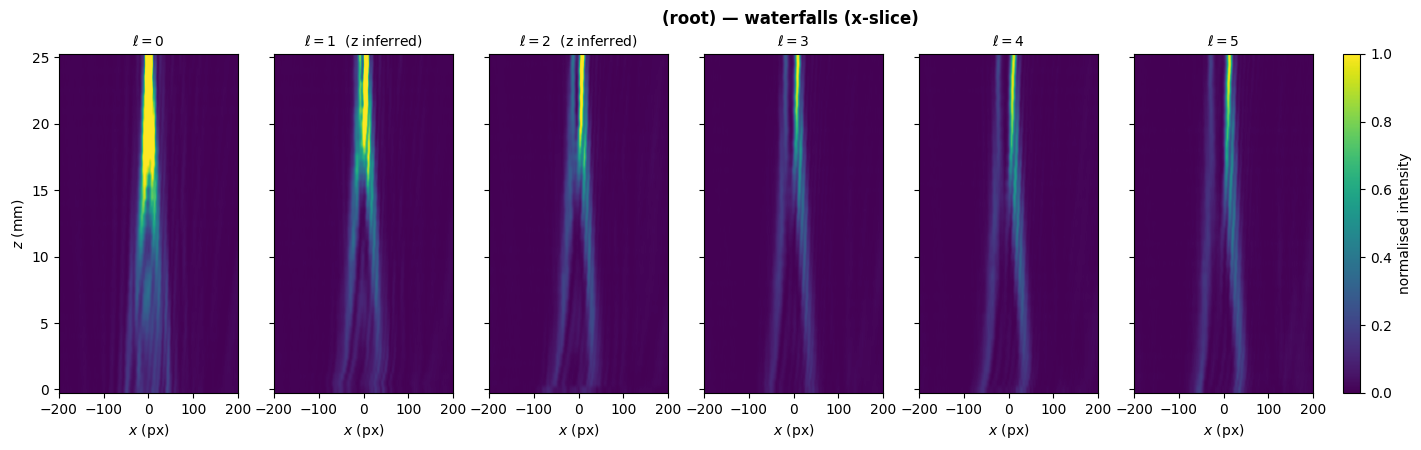

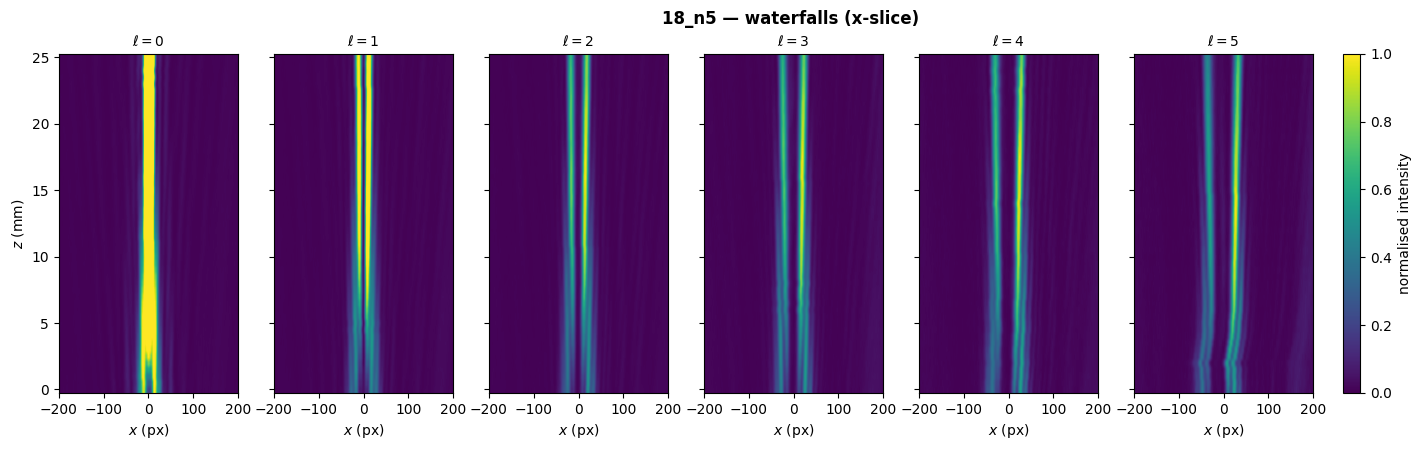

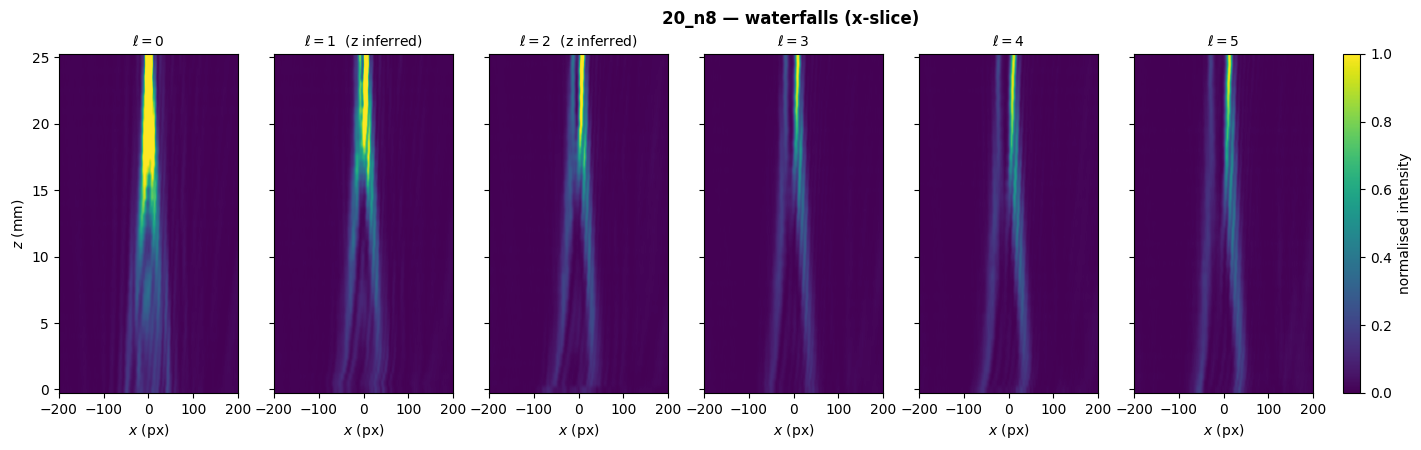

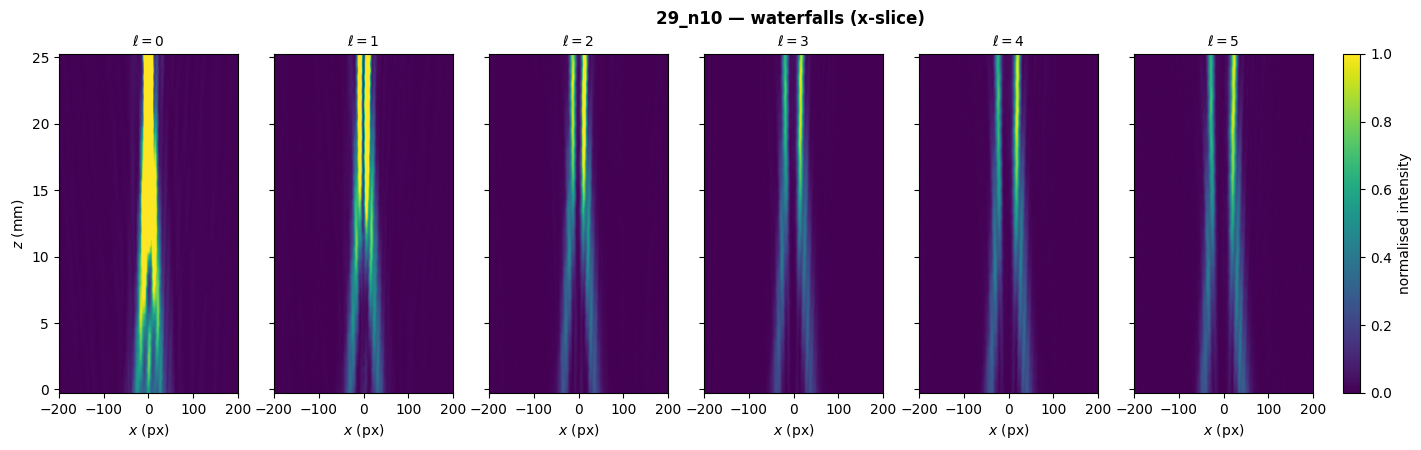

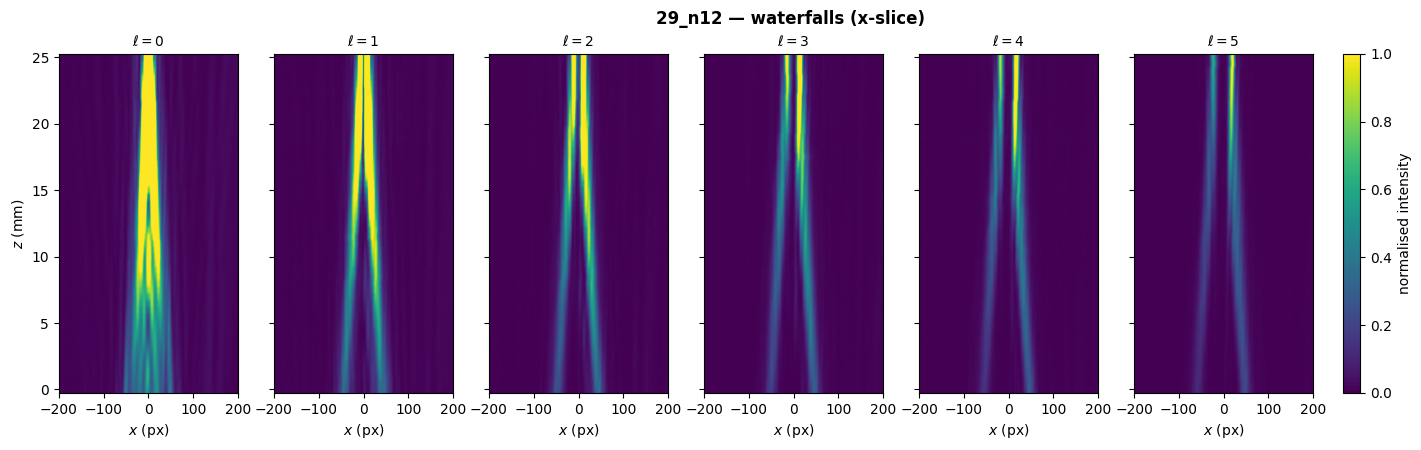

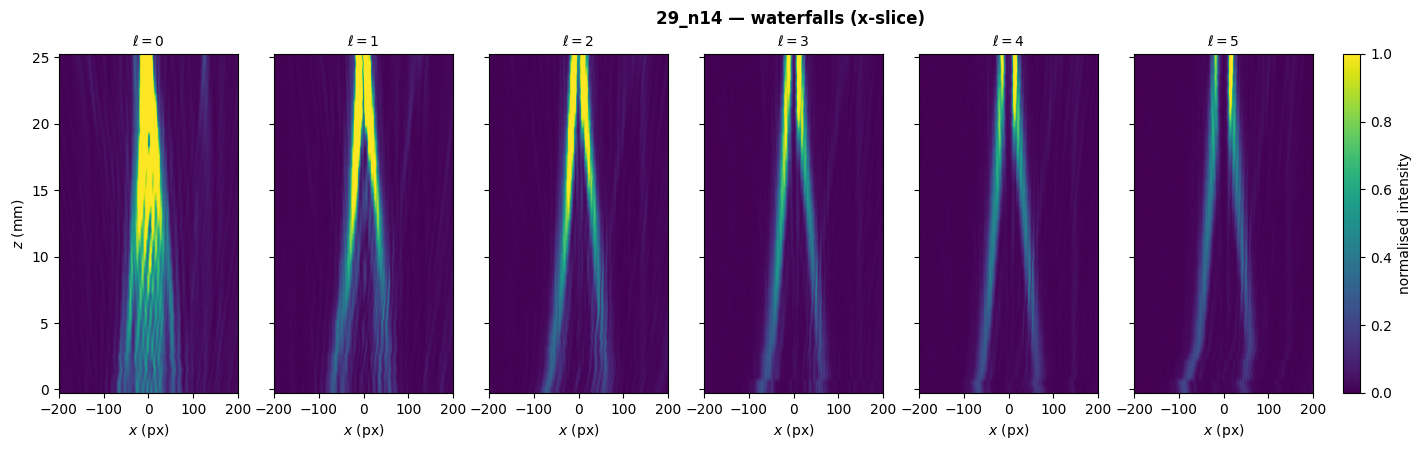

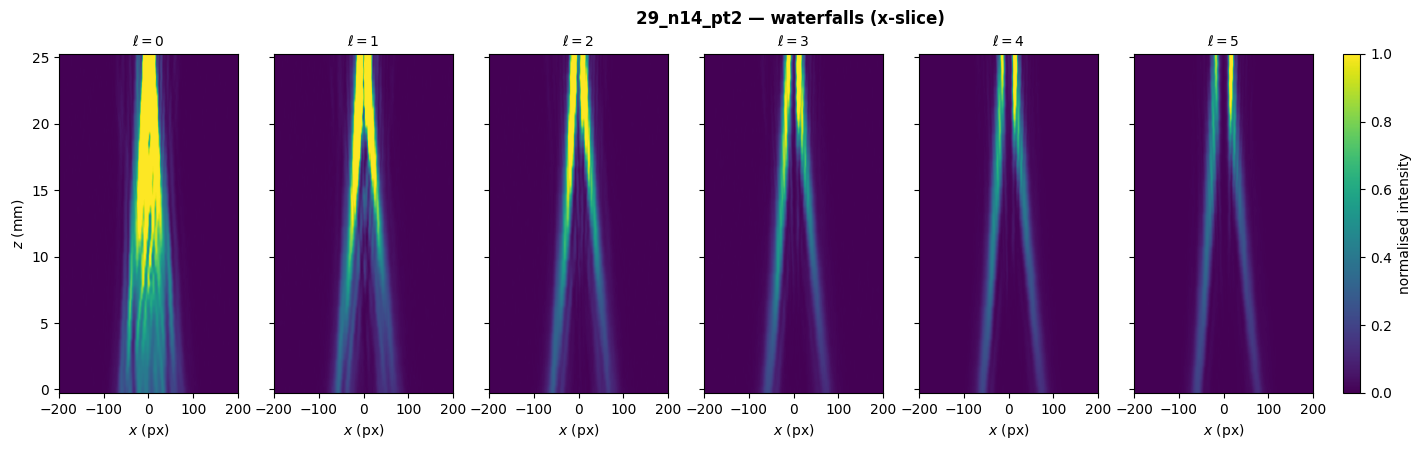

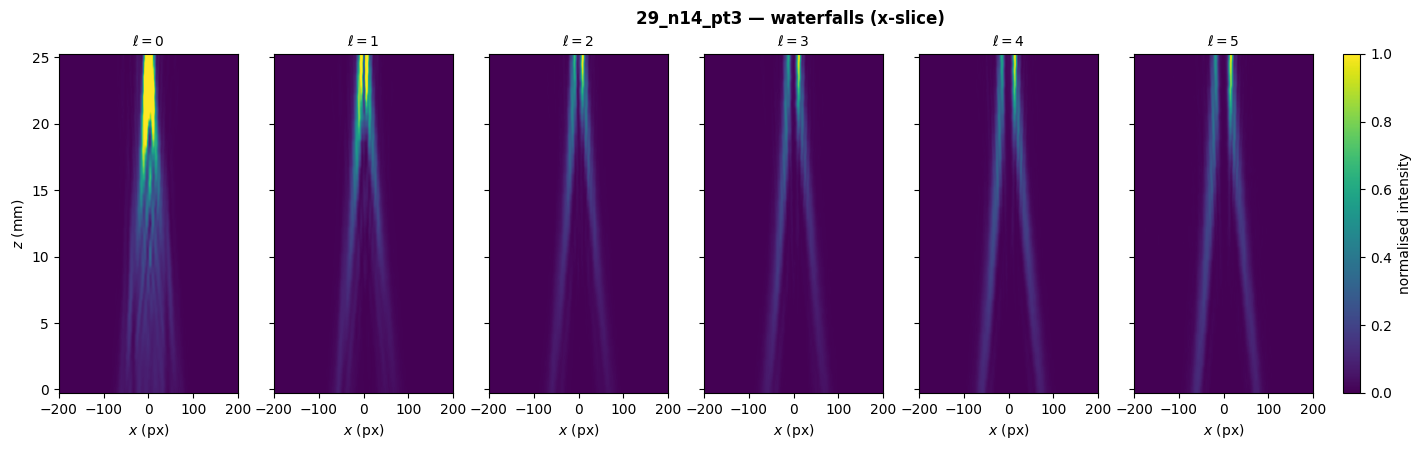

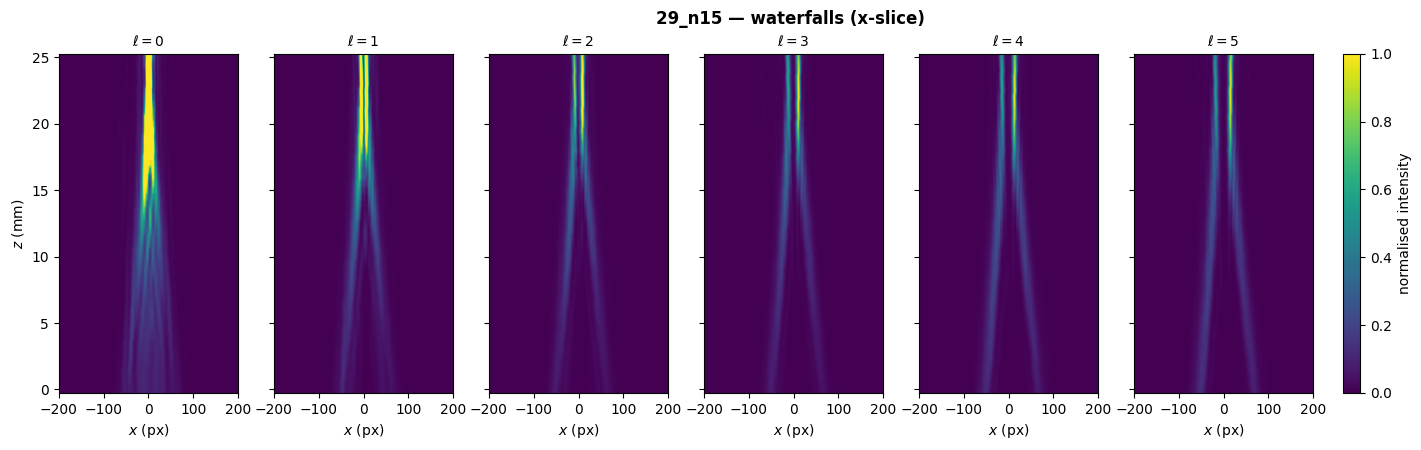

In [9]:
for run in runs_of(results):
    group = group_by_run(results, run)

    fig, axes = plt.subplots(
        1, len(group), figsize=(3.0 * len(group) + 1.5, 4.4), sharey=True, squeeze=False
    )
    for ax, result in zip(axes[0], group):
        image = draw_waterfall(ax, result)
        subtitle = "  (z inferred)" if result.inferred_positions else ""
        ax.set_title(f"$\\ell = {result.ell}${subtitle}", fontsize=10)
        ax.set_ylabel("")
    axes[0, 0].set_ylabel("$z$ (mm)")

    fig.colorbar(image, ax=axes[0].tolist(), label="normalised intensity", pad=0.02)
    fig.suptitle(f"{run} — waterfalls ({SLICE_AXIS}-slice)", fontweight="bold")

    save_and_show(fig, OUT_ROOT / f"{run}_grid_{SLICE_AXIS}.png", bbox_inches="tight")

## Diagnostic: is the centroid jumping around?

A smooth, slowly-varying trace means the tracking is stable and the waterfall slice is
meaningful. Sharp excursions — especially near focus, where the donut collapses and the
ring symmetry breaks — mean the slice line is unreliable at those distances.

One figure per run now overlays all $\ell$ of that run, so a single bad trace stands out
against its siblings, which were taken under the same alignment. Saved to
`outputs/waterfalls/<run>_centroids.png`.

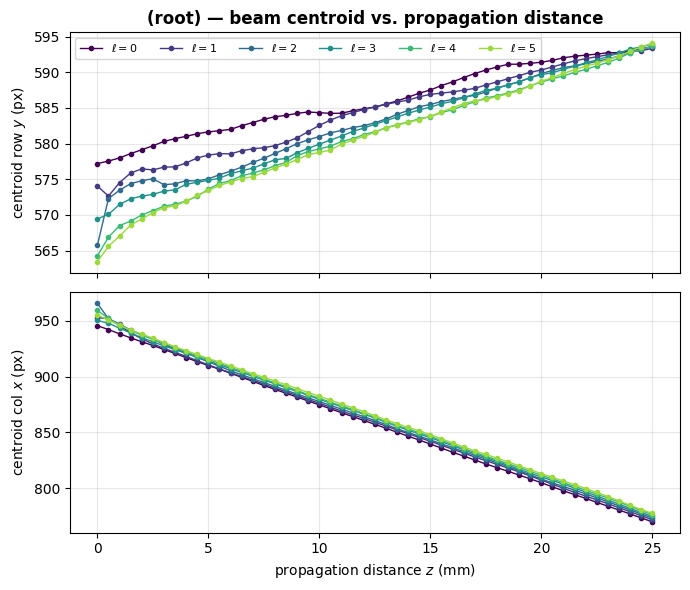

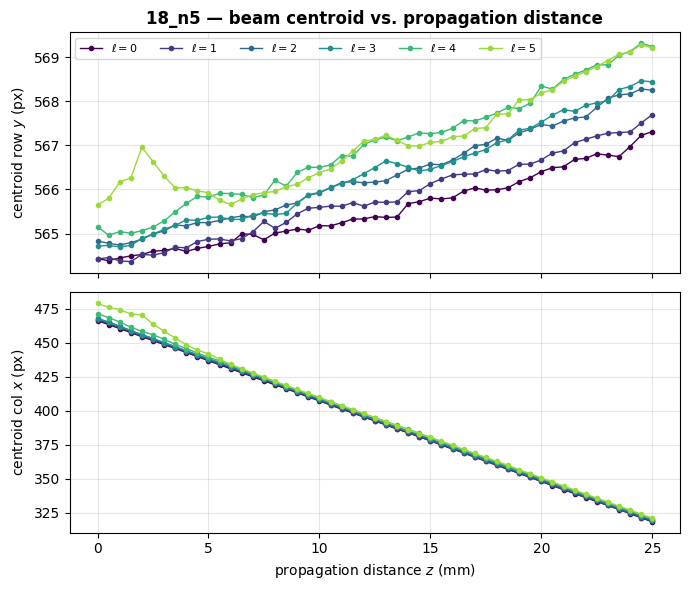

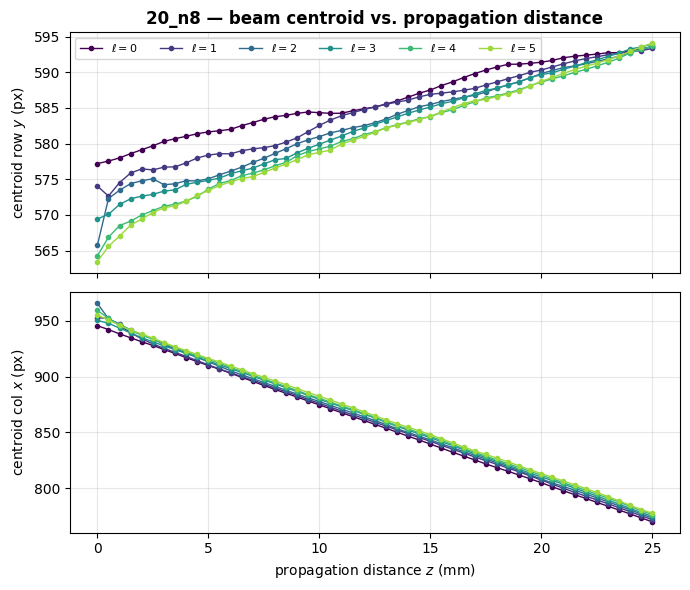

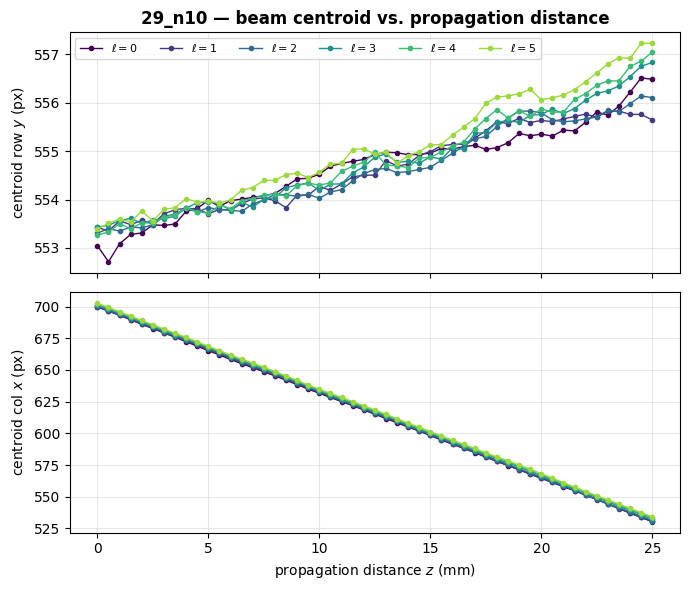

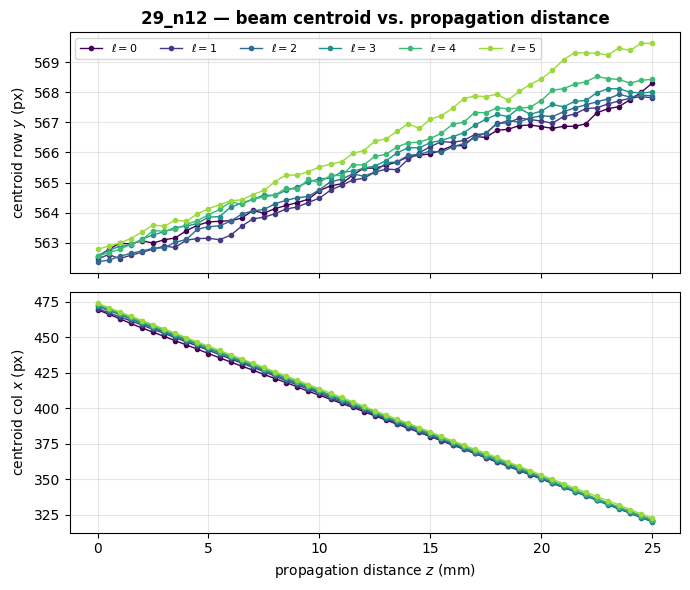

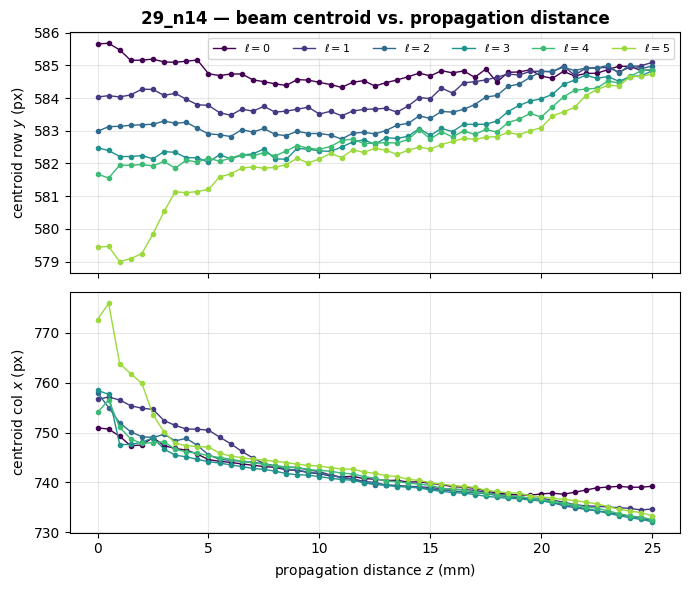

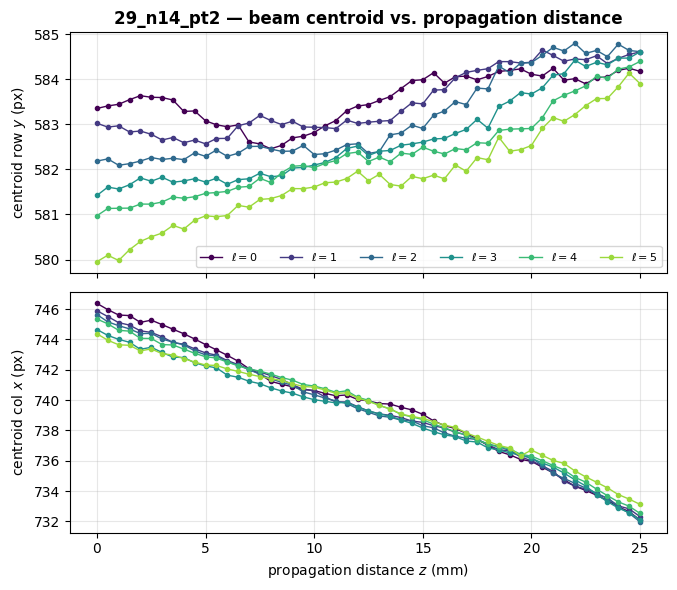

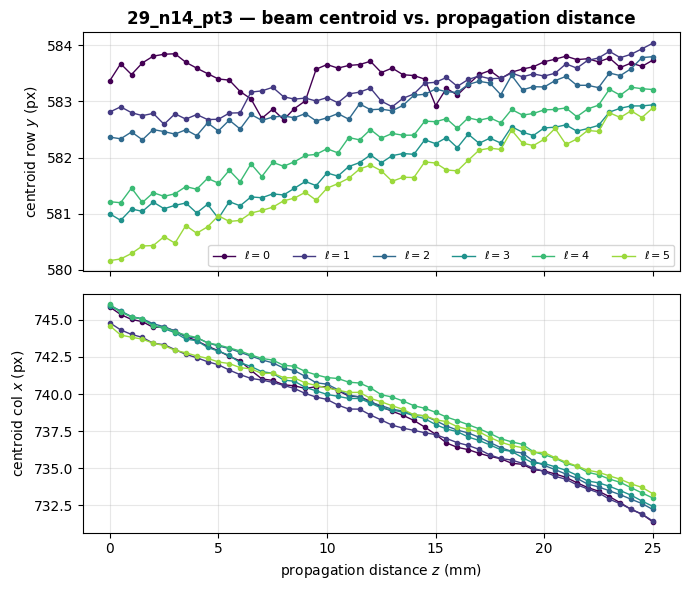

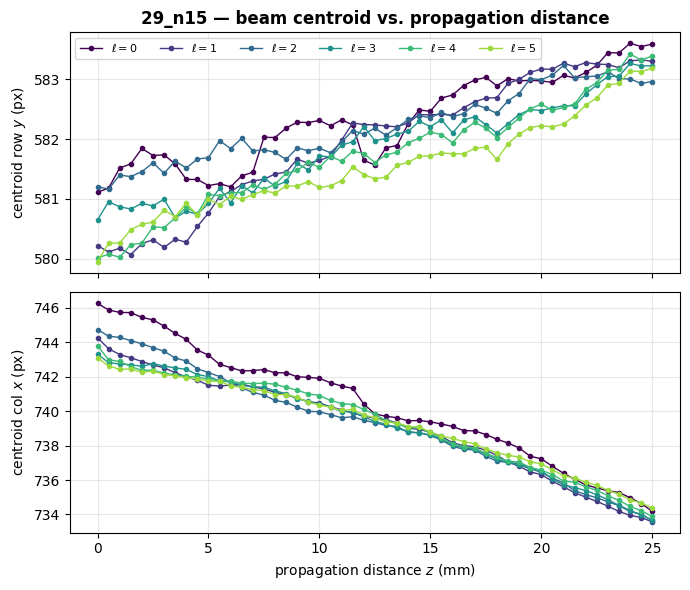

In [10]:
for run in runs_of(results):
    group = group_by_run(results, run)
    colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(group)))

    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
    for result, colour in zip(group, colours):
        axes[0].plot(
            result.z_mm, result.centroid_y, "o-", ms=3, lw=1,
            color=colour, label=f"$\\ell = {result.ell}$",
        )
        axes[1].plot(result.z_mm, result.centroid_x, "o-", ms=3, lw=1, color=colour)

    axes[0].set_ylabel("centroid row $y$ (px)")
    axes[0].set_title(f"{run} — beam centroid vs. propagation distance", fontweight="bold")
    axes[0].legend(ncol=len(group), fontsize=8)
    axes[1].set_ylabel("centroid col $x$ (px)")
    axes[1].set_xlabel("propagation distance $z$ (mm)")
    for ax in axes:
        ax.grid(alpha=0.3)

    fig.tight_layout()
    save_and_show(fig, OUT_ROOT / f"{run}_centroids.png")

## Summary table

The drift and step-to-step-std numbers that used to be printed for the single folder, now
one row per dataset. `row_drift_px` / `col_drift_px` are peak-to-peak excursions of the
centroid over the whole scan; the `*_step_std_px` columns are the std of the frame-to-frame
change, which is the quantity that catches a centroid *hopping* rather than drifting.
`inferred` marks the datasets whose z axis came from `STEP_MM` rather than a
`positions.csv`.

In [11]:
summary = pd.DataFrame(
    [
        {
            "run": r.run,
            "ell": r.ell,
            "axis": r.axis,
            "n_frames": r.z_mm.size,
            "z_min_mm": r.z_mm.min(),
            "z_max_mm": r.z_mm.max(),
            "brightest_z_mm": r.brightest_z,
            "row_drift_px": np.ptp(r.centroid_y),
            "col_drift_px": np.ptp(r.centroid_x),
            "row_step_std_px": np.diff(r.centroid_y).std(),
            "col_step_std_px": np.diff(r.centroid_x).std(),
            "inferred": r.inferred_positions,
        }
        for r in results
    ]
).round(2)

with pd.option_context("display.max_rows", None, "display.width", 160):
    display(summary)

,run,ell,axis,n_frames,z_min_mm,z_max_mm,brightest_z_mm,row_drift_px,col_drift_px,row_step_std_px,col_step_std_px,inferred
0,(root),0,x,51,0.0,25.0,16.0,16.39,175.63,0.18,0.13,False
1,(root),1,x,51,0.0,25.0,18.5,20.68,180.86,0.41,0.78,True
2,(root),2,x,51,0.0,25.0,19.5,27.87,192.22,0.89,1.49,True
3,(root),3,x,51,0.0,25.0,23.5,24.53,175.43,0.19,0.28,False
4,(root),4,x,51,0.0,25.0,23.0,29.34,182.75,0.36,0.68,False
5,(root),5,x,51,0.0,25.0,24.5,30.61,177.61,0.32,0.32,False
6,18_n5,0,x,51,0.0,25.0,0.0,2.92,147.94,0.08,0.11,False
7,18_n5,1,x,51,0.0,25.0,8.0,3.33,148.42,0.08,0.10,False
8,18_n5,2,x,51,0.0,25.0,16.0,3.54,148.46,0.07,0.12,False
9,18_n5,3,x,51,0.0,25.0,16.0,3.77,147.93,0.08,0.09,False
